[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gouravkhanijoe13/agentic-ai-lab/blob/main/Lesson_61_Agent_Bench.ipynb)

# Lesson 61 — `agent-bench`: Building an Agent Benchmark Harness

**Phase 6 · OSS Builder Phase**

| # | Lesson | Status |
|---|--------|--------|
| L56 | Phase 6 Kickoff — decision matrix, paper-distiller chosen | ✅ |
| L57 | Core Pipeline + Golden Eval Harness (section detection, scanned-PDF fallback, batch, evals) | ✅ |
| L58 | Typer CLI + PyPI Packaging | ✅ |
| L59 | Web API (FastAPI, async jobs, deployment) | ✅ |
| L60 | OSS Growth (README, badges, CONTRIBUTING funnel, launch) | ✅ |
| **L61** | **agent-bench — a general-purpose agent benchmark harness** | 👉 today |
| L62 | External Data (real corpora, retrieval sources) | ⏭️ |
| L63 | Safety (jailbreak/moderation pass on paper-distiller) | ⏭️ |
| L64 | Launch Day | ⏭️ |

**Where this fits:** L57 gave paper-distiller a *golden eval harness* — a good pattern, but hardcoded to one pipeline and one judge. Today we generalize that pattern into `agent-bench`: a small, reusable framework for benchmarking *any* agent (a Claude tool-use loop, a CLI, paper-distiller's `extract_digest()`, someone else's agent entirely) against a *task suite*, with pluggable scorers and CI-gated regression detection. This is the same shape as SWE-bench / GAIA / τ-bench, just built by hand so you understand what's under the hood before you ever import one.

## 1. Why a *dedicated* agent benchmark (not just an eval harness)

An LLM eval (MMLU, HumanEval) scores a single forward pass: prompt in, answer out, check it. An **agent benchmark** scores a *trajectory* — the agent may call tools, read files, take multiple turns, and change the state of an environment before it's done. That's a different measurement problem: you need an **environment** to interact with, a **success criterion** that can be checked programmatically (not just "does the text look right"), and a way to handle the fact that agents are often non-deterministic.

### The current (2026) landscape

| Benchmark | Domain | Environment | Scoring | Best for |
|---|---|---|---|---|
| **SWE-bench Verified** | Real GitHub issues | Cloned repo + test suite | Unit tests pass/fail | Coding agents |
| **GAIA** | General assistant tasks | Web + tools + files | Exact-match final answer | Broad reasoning + tool use |
| **Tau²-Bench** | Customer-service style dialogs | Simulated user + policy | Policy adherence + task success | Tool-agent-*user* interaction |
| **WebArena** | Realistic websites | Live browser sandbox | Functional outcome (e.g. "item in cart") | Web-navigation agents |
| **OSWorld** | Real desktop OS | VM with GUI | Functional outcome | Computer-use agents |
| **Terminal-Bench** | Shell tasks | Sandboxed terminal | Exit code / file state | CLI / systems agents |
| **METR Time Horizons (HCAST)** | Mixed | Varies | Longest task completed 50% of the time | Capability trend-tracking over time |
| **AgentBench** | 8 environments (DB, OS, web shopping, etc.) | Mixed | Per-environment success | Cross-domain agent comparison |

The single most important fact about agent benchmarks in 2026: **the scaffolding around a model routinely moves the score more than the model does** — a 30-50 point spread has been observed on identical tasks depending on framework/tooling. That's the whole reason to build your *own* harness: you want to benchmark *your* agent's actual behavior, not borrow someone else's scaffold and mistake its score for your agent's capability.

**Design goal for today:** a harness small enough to read in one sitting, general enough to benchmark paper-distiller *and* a toy tool-use agent *and* (with a few lines) a completely different agent later.

In [1]:
# Setup
!pip install anthropic pydantic rich pandas matplotlib scipy -q

import os, json, time, random, hashlib, asyncio
from dataclasses import dataclass, field
from typing import Any, Callable, Literal, Optional
from enum import Enum

from pydantic import BaseModel, Field
from rich.console import Console
from rich.table import Table
import pandas as pd
import matplotlib.pyplot as plt

console = Console()

try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
except Exception:
    ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')

HAVE_API_KEY = bool(ANTHROPIC_API_KEY)
if HAVE_API_KEY:
    os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY

print(f"Live Claude calls available: {HAVE_API_KEY}")
print("(If False: every live-agent cell below auto-falls-back to a scripted MockAgent so the notebook still runs top-to-bottom.)")

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Live Claude calls available: False
(If False: every live-agent cell below auto-falls-back to a scripted MockAgent so the notebook still runs top-to-bottom.)


## 2. Anatomy of a benchmark harness

```
                    ┌────────────────────────────────────────┐
                    │              BenchmarkRunner              │
                    └────────────────────────────────────────┘
                                     │  for each (agent, task) pair
                                     ▼
   Task ──► Environment.reset() ──► Agent.act(obs, tools) ──► Environment.step()
                                     │  (loop until done/max_steps)
                                     ▼
                              Trajectory (full transcript)
                                     │
                                     ▼
                          Scorer(task, trajectory, final_state) ──► TaskResult
                                     │
                                     ▼
                    aggregate over N tasks × K attempts ──► pass@k, cost, latency
```

Five pieces, each independently swappable:

1. **Task** — id, category, difficulty, the prompt, and a success criterion.
2. **Environment** — the sandbox the agent acts in (tools + state). Different tasks may need different environments.
3. **Agent** — anything with an `act()` method. Could be a Claude tool-use loop, a deterministic script, or a wrapped third-party agent.
4. **Scorer** — turns a finished trajectory into pass/fail (+ optional partial credit). Three flavors: exact-match, unit-test (execute an assertion against final state — this is what SWE-bench actually does), and LLM-judge (for open-ended answers).
5. **Runner** — orchestrates the above across a task suite, handles retries for pass@k, and produces a report.

In [2]:
# --- 1. Task ---------------------------------------------------------

class Task(BaseModel):
    id: str
    category: Literal["tool_use", "file_edit", "knowledge_qa"]
    difficulty: Literal["easy", "medium", "hard"]
    prompt: str
    env_name: str                      # which Environment to instantiate
    env_kwargs: dict = Field(default_factory=dict)
    # success criterion is a callable name resolved at run time (see Scorers section)
    scorer_name: str
    scorer_kwargs: dict = Field(default_factory=dict)

@dataclass
class TrajectoryStep:
    role: Literal["agent", "tool", "env"]
    content: str
    tool_name: Optional[str] = None
    tool_input: Optional[dict] = None

@dataclass
class Trajectory:
    task_id: str
    steps: list = field(default_factory=list)
    final_state: dict = field(default_factory=dict)
    n_tool_calls: int = 0
    cost_usd: float = 0.0
    latency_s: float = 0.0

@dataclass
class TaskResult:
    task_id: str
    attempt: int
    passed: bool
    score: float               # 0.0-1.0, partial credit where scorer supports it
    reason: str
    trajectory: Trajectory

print("Task / Trajectory / TaskResult defined.")

Task / Trajectory / TaskResult defined.


In [3]:
# --- 2. Environments ---------------------------------------------------
# Three tiny sandboxes, deliberately simple so the harness logic stays visible.
# Each exposes: reset() -> observation str, tools() -> list[dict] (Anthropic tool schema),
# call_tool(name, input) -> str (tool_result text), and state() -> dict (for scoring).

class CalcEnv:
    # Tool-use environment: agent must use a calculator tool, not do arithmetic itself.
    def __init__(self):
        self.history = []

    def reset(self, task: Task):
        self.history = []
        return f"You have access to a `calculate` tool. {task.prompt}"

    def tools(self):
        return [{
            "name": "calculate",
            "description": "Evaluate a basic arithmetic expression, e.g. '12 * (4 + 1)'.",
            "input_schema": {
                "type": "object",
                "properties": {"expression": {"type": "string"}},
                "required": ["expression"],
            },
        }]

    def call_tool(self, name: str, tool_input: dict) -> str:
        if name != "calculate":
            return f"error: unknown tool {name}"
        expr = tool_input.get("expression", "")
        # safe eval: digits, operators, parens, whitespace only
        if not all(c in "0123456789+-*/(). " for c in expr):
            return "error: expression contains disallowed characters"
        try:
            result = eval(expr, {"__builtins__": {}}, {})
        except Exception as e:
            return f"error: {e}"
        self.history.append((expr, result))
        return str(result)

    def state(self):
        return {"history": self.history}


class FileEnv:
    # File-edit environment: an in-memory virtual filesystem, SWE-bench-style task shape
    # (fix a bug, then a hidden 'test' checks the file content).
    def __init__(self, files: dict):
        self.files = dict(files)  # seed files
        self.edits = 0

    def reset(self, task: Task):
        listing = "\n".join(f"- {name}" for name in self.files)
        return f"{task.prompt}\n\nFiles available:\n{listing}"

    def tools(self):
        return [
            {"name": "read_file", "description": "Read a file's contents.",
             "input_schema": {"type": "object", "properties": {"path": {"type": "string"}}, "required": ["path"]}},
            {"name": "write_file", "description": "Overwrite a file's contents.",
             "input_schema": {"type": "object", "properties": {
                 "path": {"type": "string"}, "content": {"type": "string"}}, "required": ["path", "content"]}},
        ]

    def call_tool(self, name: str, tool_input: dict) -> str:
        if name == "read_file":
            return self.files.get(tool_input.get("path", ""), "error: file not found")
        if name == "write_file":
            self.files[tool_input["path"]] = tool_input["content"]
            self.edits += 1
            return "ok"
        return f"error: unknown tool {name}"

    def state(self):
        return {"files": dict(self.files), "edits": self.edits}


class KnowledgeEnv:
    # Knowledge-QA environment: a small fixed corpus + a lookup tool (mini-GAIA shape:
    # the agent must retrieve the fact, not guess).
    CORPUS = {
        "attention_paper": "The paper 'Attention Is All You Need' (Vaswani et al., 2017) introduced the Transformer architecture, which relies entirely on self-attention and discards recurrence and convolution.",
        "paged_attention": "PagedAttention (used in vLLM) manages the KV cache as fixed-size non-contiguous blocks, similar to virtual memory paging, to eliminate memory fragmentation.",
        "dpo": "Direct Preference Optimization (DPO) reframes RLHF as a single classification-style loss over preference pairs, avoiding a separate reward model and PPO.",
    }

    def reset(self, task: Task):
        return f"You have a `lookup` tool over a small internal corpus. {task.prompt}"

    def tools(self):
        return [{
            "name": "lookup",
            "description": "Look up a topic key in the internal knowledge corpus.",
            "input_schema": {"type": "object", "properties": {"key": {"type": "string"}}, "required": ["key"]},
        }]

    def call_tool(self, name: str, tool_input: dict) -> str:
        if name != "lookup":
            return f"error: unknown tool {name}"
        return self.CORPUS.get(tool_input.get("key", ""), "error: no such entry")

    def state(self):
        return {}

ENVIRONMENTS = {"calc": CalcEnv, "file": FileEnv, "knowledge": KnowledgeEnv}
print("3 environments registered:", list(ENVIRONMENTS))

3 environments registered: ['calc', 'file', 'knowledge']


## 3. Agents

An **Agent** just needs an `act(observation, tools, history) -> (final_text, tool_call_or_None)` method. We build two: a `MockAgent` (fully deterministic — this is what makes the harness itself testable and what lets this notebook run end-to-end with zero API cost) and a `ClaudeToolAgent` (a real tool-use loop against Sonnet/Haiku). The harness doesn't care which one it's running — that's the point.

In [4]:
# --- 3. Agents -----------------------------------------------------

class Agent:
    # Protocol: anything with .act(...) can be benchmarked.
    name: str
    def act(self, observation: str, tools: list, history: list) -> dict:
        raise NotImplementedError


class MockAgent(Agent):
    # Deterministic scripted agent used to validate the harness itself (zero cost,
    # zero flakiness). scripts: dict[task_id] -> list of (tool_name, tool_input) then a
    # final text answer.
    name = "mock-agent"

    def __init__(self, scripts: dict, flake_rate: float = 0.0):
        self.scripts = scripts
        self.flake_rate = flake_rate  # inject randomness to demo pass@1 vs pass@k later

    def run(self, task: Task, env) -> Trajectory:
        traj = Trajectory(task_id=task.id)
        obs = env.reset(task)
        traj.steps.append(TrajectoryStep(role="env", content=obs))
        script = self.scripts.get(task.id, [])
        for step in script:
            if random.random() < self.flake_rate:
                # simulate a flaky wrong tool call
                traj.steps.append(TrajectoryStep(role="agent", content="(flaky misfire)"))
                continue
            if isinstance(step, tuple):
                tool_name, tool_input = step
                result = env.call_tool(tool_name, tool_input)
                traj.n_tool_calls += 1
                traj.steps.append(TrajectoryStep(role="agent", content="", tool_name=tool_name, tool_input=tool_input))
                traj.steps.append(TrajectoryStep(role="tool", content=result, tool_name=tool_name))
            else:
                traj.steps.append(TrajectoryStep(role="agent", content=step))
        traj.final_state = env.state()
        return traj


class ClaudeToolAgent(Agent):
    # Real Claude tool-use loop. Falls back gracefully if no API key (caller checks
    # HAVE_API_KEY before using this).
    name = "claude-haiku-agent"

    def __init__(self, model="claude-haiku-4-5", max_turns=6):
        from anthropic import Anthropic
        self.client = Anthropic()
        self.model = model
        self.max_turns = max_turns

    def run(self, task: Task, env) -> Trajectory:
        import anthropic
        traj = Trajectory(task_id=task.id)
        obs = env.reset(task)
        traj.steps.append(TrajectoryStep(role="env", content=obs))
        messages = [{"role": "user", "content": obs}]
        t0 = time.time()
        for _ in range(self.max_turns):
            resp = self.client.messages.create(
                model=self.model, max_tokens=512,
                tools=env.tools(), messages=messages,
            )
            traj.cost_usd += _estimate_cost(self.model, resp.usage.input_tokens, resp.usage.output_tokens)
            tool_used = False
            assistant_content = []
            for block in resp.content:
                if block.type == "text" and block.text.strip():
                    traj.steps.append(TrajectoryStep(role="agent", content=block.text))
                    assistant_content.append({"type": "text", "text": block.text})
                elif block.type == "tool_use":
                    tool_used = True
                    result = env.call_tool(block.name, block.input)
                    traj.n_tool_calls += 1
                    traj.steps.append(TrajectoryStep(role="agent", content="", tool_name=block.name, tool_input=block.input))
                    traj.steps.append(TrajectoryStep(role="tool", content=result, tool_name=block.name))
                    assistant_content.append({"type": "tool_use", "id": block.id, "name": block.name, "input": block.input})
                    messages.append({"role": "assistant", "content": assistant_content})
                    messages.append({"role": "user", "content": [
                        {"type": "tool_result", "tool_use_id": block.id, "content": result}]})
                    break
            if not tool_used:
                break
        traj.latency_s = time.time() - t0
        traj.final_state = env.state()
        return traj


def _estimate_cost(model, in_tok, out_tok):
    prices = {"claude-haiku-4-5": (0.80, 4.00), "claude-sonnet-4-5": (3.00, 15.00)}
    in_p, out_p = prices.get(model, (1.0, 5.0))
    return (in_tok / 1e6) * in_p + (out_tok / 1e6) * out_p

print("Agent protocol + MockAgent + ClaudeToolAgent defined.")

Agent protocol + MockAgent + ClaudeToolAgent defined.


## 4. Scorers

Three flavors, matching how the real benchmarks in the landscape table actually score:

- **`exact_match`** — cheapest, zero flakiness, only works when there's one right literal answer (GAIA-style).
- **`unit_test`** — run an assertion function against `trajectory.final_state`. This is *literally* what SWE-bench does (does the patched repo pass the hidden test suite?). Best signal, zero LLM cost, but you have to write the assertion by hand per task.
- **`llm_judge`** — for open-ended output where there's no single right string. Cheap to write, but is itself a noisy measurement instrument (see Pitfall #3 below) — never your only scorer for a task that could be checked programmatically instead.

In [5]:
# --- 4. Scorers ------------------------------------------------------

def scorer_exact_match(task: Task, traj: Trajectory, expected: str) -> TaskResult:
    last_text = next((s.content for s in reversed(traj.steps) if s.role == "agent" and s.content), "")
    passed = expected.strip().lower() in last_text.strip().lower()
    return TaskResult(task.id, 0, passed, 1.0 if passed else 0.0,
                       f"expected substring {expected!r} {'found' if passed else 'NOT found'} in final answer",
                       traj)


def scorer_unit_test(task: Task, traj: Trajectory, check_fn: Callable[[dict], bool], reason: str) -> TaskResult:
    try:
        passed = bool(check_fn(traj.final_state))
    except Exception as e:
        passed = False
        reason = f"assertion raised: {e}"
    return TaskResult(task.id, 0, passed, 1.0 if passed else 0.0, reason, traj)


JUDGE_TOOL = {
    "name": "score_response",
    "description": "Score whether the agent's final answer correctly satisfies the task.",
    "input_schema": {
        "type": "object",
        "properties": {
            "passed": {"type": "boolean"},
            "score": {"type": "number", "description": "0.0-1.0 partial credit"},
            "reason": {"type": "string"},
        },
        "required": ["passed", "score", "reason"],
    },
}

def scorer_llm_judge(task: Task, traj: Trajectory, rubric: str, client=None) -> TaskResult:
    last_text = next((s.content for s in reversed(traj.steps) if s.role == "agent" and s.content), "")
    if not HAVE_API_KEY:
        # deterministic offline fallback so the harness stays testable without a key
        passed = len(last_text.strip()) > 0
        return TaskResult(task.id, 0, passed, 0.5, "offline fallback: judge skipped (no API key), length-only check", traj)
    from anthropic import Anthropic
    client = client or Anthropic()
    resp = client.messages.create(
        model="claude-haiku-4-5", max_tokens=300,
        tools=[JUDGE_TOOL], tool_choice={"type": "tool", "name": "score_response"},
        messages=[{"role": "user", "content": f"Task: {task.prompt}\nRubric: {rubric}\nAgent's final answer: {last_text}"}],
    )
    verdict = resp.content[0].input
    return TaskResult(task.id, 0, verdict["passed"], verdict["score"], verdict["reason"], traj)

SCORERS = {"exact_match": scorer_exact_match, "unit_test": scorer_unit_test, "llm_judge": scorer_llm_judge}
print("3 scorers registered:", list(SCORERS))

3 scorers registered: ['exact_match', 'unit_test', 'llm_judge']


## 5. The task suite

Eight tasks across the three environments — small on purpose. A benchmark suite you can read end-to-end in five minutes is more useful for CI than a 500-task suite you've never actually read (see Pitfall #6).

In [6]:
# --- 5. Task suite ---------------------------------------------------

TASKS = [
    Task(id="calc-1", category="tool_use", difficulty="easy",
         prompt="What is 47 * 19? Use the calculate tool, don't do it in your head.",
         env_name="calc", scorer_name="exact_match", scorer_kwargs={"expected": "893"}),
    Task(id="calc-2", category="tool_use", difficulty="medium",
         prompt="What is (128 + 372) / 4? Use the calculate tool.",
         env_name="calc", scorer_name="exact_match", scorer_kwargs={"expected": "125"}),
    Task(id="file-1", category="file_edit", difficulty="medium",
         prompt="config.yaml has debug: true. Read it, then write it back with debug set to false.",
         env_name="file", env_kwargs={"files": {"config.yaml": "debug: true\nport: 8080\n"}},
         scorer_name="unit_test", scorer_kwargs={"reason": "debug should be false, port untouched"}),
    Task(id="file-2", category="file_edit", difficulty="hard",
         prompt="notes.txt contains a typo: 'teh' should be 'the'. Read it, fix the typo, write it back preserving everything else.",
         env_name="file", env_kwargs={"files": {"notes.txt": "This is teh best lesson so far.\n"}},
         scorer_name="unit_test", scorer_kwargs={"reason": "typo fixed, rest of sentence preserved"}),
    Task(id="know-1", category="knowledge_qa", difficulty="easy",
         prompt="Look up 'attention_paper' and tell me what year it was published.",
         env_name="knowledge", scorer_name="exact_match", scorer_kwargs={"expected": "2017"}),
    Task(id="know-2", category="knowledge_qa", difficulty="medium",
         prompt="Look up 'paged_attention' and summarize the core idea in one sentence.",
         env_name="knowledge", scorer_name="llm_judge",
         scorer_kwargs={"rubric": "Mentions KV cache managed as non-contiguous blocks / virtual-memory-style paging."}),
    Task(id="know-3", category="knowledge_qa", difficulty="medium",
         prompt="Look up 'dpo' and explain what it avoids needing, compared to RLHF.",
         env_name="knowledge", scorer_name="llm_judge",
         scorer_kwargs={"rubric": "Mentions avoiding a separate reward model and/or PPO."}),
    Task(id="calc-3", category="tool_use", difficulty="hard",
         prompt="What is 15% of 340? Use the calculate tool.",
         env_name="calc", scorer_name="exact_match", scorer_kwargs={"expected": "51"}),
]

print(f"{len(TASKS)} tasks across categories:", pd.Series([t.category for t in TASKS]).value_counts().to_dict())

8 tasks across categories: {'tool_use': 3, 'knowledge_qa': 3, 'file_edit': 2}


In [7]:
# --- 6. Runner --------------------------------------------------------

class BenchmarkRunner:
    def __init__(self, tasks: list, environments: dict, scorers: dict):
        self.tasks = tasks
        self.environments = environments
        self.scorers = scorers

    def _score(self, task: Task, traj: Trajectory) -> TaskResult:
        scorer = self.scorers[task.scorer_name]
        if task.scorer_name == "unit_test":
            check_fn = UNIT_TESTS[task.id]
            return scorer(task, traj, check_fn, task.scorer_kwargs.get("reason", ""))
        if task.scorer_name == "exact_match":
            return scorer(task, traj, task.scorer_kwargs["expected"])
        if task.scorer_name == "llm_judge":
            return scorer(task, traj, task.scorer_kwargs["rubric"])
        raise ValueError(f"unknown scorer {task.scorer_name}")

    def run(self, agent, k: int = 1, verbose: bool = False) -> list:
        # Run `agent` against every task, `k` attempts each (for pass@k).
        results = []
        for task in self.tasks:
            for attempt in range(k):
                env = self.environments[task.env_name](**task.env_kwargs)
                traj = agent.run(task, env)
                result = self._score(task, traj)
                result.attempt = attempt
                results.append(result)
                if verbose:
                    mark = "✅" if result.passed else "❌"
                    console.print(f"{mark} [{task.category}/{task.difficulty}] {task.id} (attempt {attempt}) — {result.reason}")
        return results


UNIT_TESTS = {
    "file-1": lambda state: "debug: false" in state["files"]["config.yaml"] and "port: 8080" in state["files"]["config.yaml"],
    "file-2": lambda state: "the best lesson" in state["files"]["notes.txt"] and "teh" not in state["files"]["notes.txt"],
}

print("BenchmarkRunner ready.")

BenchmarkRunner ready.


## 6. pass@k, and why pass@1 alone is misleading

A single run against a flaky agent tells you almost nothing — the same task can pass 90% of the time on one seed and 50% on another. The fix, from the Codex paper (Chen et al., 2021), is the **unbiased pass@k estimator**: instead of literally running k times and checking "did at least one pass" (which is itself noisy for small k), sample `n ≥ k` attempts and compute

```
pass@k = 1 - C(n - c, k) / C(n, k)
```

where `c` is the number of correct attempts out of `n`. We'll run a *deliberately flaky* MockAgent (misfires 25% of the time) to make the pass@1-vs-pass@5 gap visible.

In [8]:
# --- 7. pass@k -------------------------------------------------------
from math import comb

def pass_at_k(n: int, c: int, k: int) -> float:
    # Unbiased estimator, Chen et al. 2021 (Codex paper).
    if n - c < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)


# a correct script for every task (used by both the clean and the flaky mock agent)
CORRECT_SCRIPTS = {
    "calc-1": [("calculate", {"expression": "47 * 19"}), "The answer is 893."],
    "calc-2": [("calculate", {"expression": "(128 + 372) / 4"}), "The answer is 125.0."],
    "calc-3": [("calculate", {"expression": "340 * 0.15"}), "15% of 340 is 51.0."],
    "file-1": [("read_file", {"path": "config.yaml"}),
               ("write_file", {"path": "config.yaml", "content": "debug: false\nport: 8080\n"}),
               "Done, debug set to false."],
    "file-2": [("read_file", {"path": "notes.txt"}),
               ("write_file", {"path": "notes.txt", "content": "This is the best lesson so far.\n"}),
               "Fixed the typo."],
    "know-1": [("lookup", {"key": "attention_paper"}), "It was published in 2017."],
    "know-2": [("lookup", {"key": "paged_attention"}),
               "PagedAttention manages the KV cache as non-contiguous blocks, like virtual memory paging."],
    "know-3": [("lookup", {"key": "dpo"}),
               "DPO avoids needing a separate reward model and the PPO reinforcement learning step."],
}

runner = BenchmarkRunner(TASKS, ENVIRONMENTS, SCORERS)

# n=10 attempts per task, flake_rate=0.25 simulates a real, imperfect agent
flaky_agent = MockAgent(CORRECT_SCRIPTS, flake_rate=0.25)
n_attempts = 10
flaky_results = runner.run(flaky_agent, k=n_attempts, verbose=False)

df = pd.DataFrame([{"task_id": r.task_id, "passed": r.passed} for r in flaky_results])
per_task = df.groupby("task_id")["passed"].agg(["sum", "count"]).rename(columns={"sum": "c", "count": "n"})
per_task["pass@1"] = per_task.apply(lambda r: pass_at_k(int(r.n), int(r.c), 1), axis=1)
per_task["pass@5"] = per_task.apply(lambda r: pass_at_k(int(r.n), int(r.c), 5), axis=1)
print(per_task[["c", "n", "pass@1", "pass@5"]].round(3))
print(f"\nOverall mean pass@1={per_task['pass@1'].mean():.3f}  pass@5={per_task['pass@5'].mean():.3f}")
print("pass@5 > pass@1 because more attempts give the flaky agent more chances to get lucky —")
print("this is exactly why a single pass@1 number under-states what a retried agent can do,")
print("and why reporting pass@k *with the k* matters more than a bare 'accuracy' number.")

          c   n  pass@1  pass@5
task_id                        
calc-1    7  10     0.7     1.0
calc-2    8  10     0.8     1.0
calc-3    8  10     0.8     1.0
file-1    9  10     0.9     1.0
file-2    9  10     0.9     1.0
know-1    7  10     0.7     1.0
know-2   10  10     1.0     1.0
know-3   10  10     1.0     1.0

Overall mean pass@1=0.850  pass@5=1.000
pass@5 > pass@1 because more attempts give the flaky agent more chances to get lucky —
this is exactly why a single pass@1 number under-states what a retried agent can do,
and why reporting pass@k *with the k* matters more than a bare 'accuracy' number.


## 7. Sanity-check with a clean agent, then (optionally) a real Claude agent

First confirm the harness itself is correct: a zero-flake MockAgent running the *correct* scripts should score 100% on every task and every scorer type — if it doesn't, the bug is in the harness, not the agent. Then, if a live API key is available, run a real `ClaudeToolAgent` (Haiku) against the same suite with **no scripted answers** — it has to actually use the tools.

In [9]:
# Harness self-test: clean agent should pass everything
clean_agent = MockAgent(CORRECT_SCRIPTS, flake_rate=0.0)
clean_results = runner.run(clean_agent, k=1, verbose=True)
n_passed = sum(r.passed for r in clean_results)
print(f"\nHarness self-test: {n_passed}/{len(clean_results)} passed", "✅" if n_passed == len(clean_results) else "❌ investigate a scorer/task bug before trusting any agent scores")
assert n_passed == len(clean_results), "harness self-test failed — fix before benchmarking real agents"

✅  calc-1 (attempt 0) — expected substring '893' found in final answer

✅  calc-2 (attempt 0) — expected substring '125' found in final answer

✅  file-1 (attempt 0) — debug should be false, port untouched

✅  file-2 (attempt 0) — typo fixed, rest of sentence preserved

✅  know-1 (attempt 0) — expected substring '2017' found in final answer

✅  know-2 (attempt 0) — offline fallback: judge skipped (no API key), length-only check

✅  know-3 (attempt 0) — offline fallback: judge skipped (no API key), length-only check

✅  calc-3 (attempt 0) — expected substring '51' found in final answer


Harness self-test: 8/8 passed ✅


In [10]:
# Live Claude agent (real tool-use, no script) — auto-skips gracefully without a key
if HAVE_API_KEY:
    claude_agent = ClaudeToolAgent(model="claude-haiku-4-5")
    claude_results = runner.run(claude_agent, k=1, verbose=True)
    n_passed_claude = sum(r.passed for r in claude_results)
    total_cost = sum(r.trajectory.cost_usd for r in claude_results)
    print(f"\nClaude Haiku agent: {n_passed_claude}/{len(claude_results)} passed, ${total_cost:.4f} total cost")
else:
    print("No ANTHROPIC_API_KEY found — skipping the live-agent run.")
    print("EXPERIMENT: add a Colab secret named ANTHROPIC_API_KEY and re-run this cell to see")
    print("a real Claude Haiku tool-use loop scored against the exact same task suite.")
    claude_results = []

No ANTHROPIC_API_KEY found — skipping the live-agent run.
EXPERIMENT: add a Colab secret named ANTHROPIC_API_KEY and re-run this cell to see
a real Claude Haiku tool-use loop scored against the exact same task suite.


## 8. Wiring paper-distiller in as a benchmarked agent

The whole point of generalizing L57's golden harness into `agent-bench` is that it can score things that aren't a chat loop at all. Here we wrap paper-distiller's `extract_digest()`-shaped function as an `Agent` and benchmark it on a *knowledge-extraction* task — same runner, same scorer machinery, completely different underlying system.

In [11]:
# --- 8. Benchmarking a non-chat agent: a stub of paper-distiller's extractor ---

class PaperDistillerAgent(Agent):
    # Wraps a 'digest extraction' function as a benchmarkable Agent. In the real repo
    # this would import paper_distiller.extract.extract_digest; here we stub the shape
    # so the notebook runs standalone.
    name = "paper-distiller-extractor"

    def __init__(self, extract_fn: Callable[[str], dict]):
        self.extract_fn = extract_fn

    def run(self, task: Task, env) -> Trajectory:
        traj = Trajectory(task_id=task.id)
        obs = env.reset(task)
        traj.steps.append(TrajectoryStep(role="env", content=obs))
        digest = self.extract_fn(task.prompt)
        traj.steps.append(TrajectoryStep(role="agent", content=digest.get("one_liner", "")))
        traj.final_state = {"digest": digest}
        return traj


def stub_extract_digest(prompt: str) -> dict:
    # deterministic stand-in for the real Claude-backed extractor from L56/L57
    if "attention" in prompt.lower():
        return {"one_liner": "Introduces the Transformer, an architecture based purely on self-attention (2017)."}
    return {"one_liner": "No confident extraction."}

digest_task = Task(id="pd-1", category="knowledge_qa", difficulty="easy",
                    prompt="Summarize the paper 'Attention Is All You Need' in one line.",
                    env_name="knowledge", scorer_name="exact_match", scorer_kwargs={"expected": "self-attention"})

pd_agent = PaperDistillerAgent(stub_extract_digest)
pd_runner = BenchmarkRunner([digest_task], ENVIRONMENTS, SCORERS)
pd_results = pd_runner.run(pd_agent, k=1, verbose=True)
print("\nThis is the generalization win: the L57 golden harness only knew how to score")
print("paper-distiller. agent-bench scores paper-distiller, a chat agent, and a scripted")
print("mock, through the exact same Task/Scorer/Runner contract.")

✅  pd-1 (attempt 0) — expected substring 'self-attention' found in final answer


This is the generalization win: the L57 golden harness only knew how to score
paper-distiller. agent-bench scores paper-distiller, a chat agent, and a scripted
mock, through the exact same Task/Scorer/Runner contract.


## 9. Reporting: category breakdown + confidence interval, not just a headline number

A bare "73% pass rate" hides two things CI needs: which *categories* are weak, and how much that number could move on re-run just from sampling noise. We report per-category pass rate plus a **Wilson score interval** (better-behaved than a normal approximation at small n, which agent-bench suites usually are).

       category  pass_rate  n  ci_low  ci_high
0     file_edit        1.0  2   0.342      1.0
1  knowledge_qa        1.0  3   0.438      1.0
2      tool_use        1.0  3   0.438      1.0


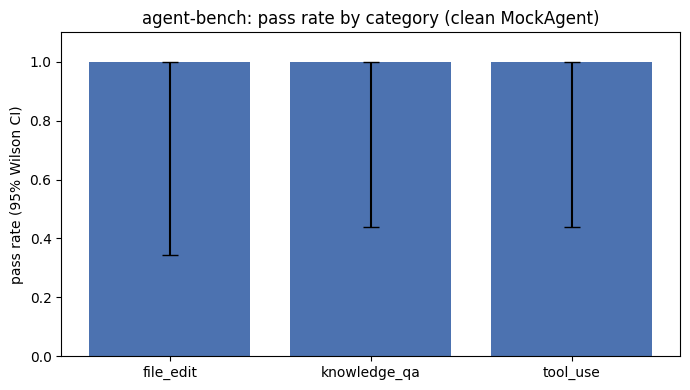

With only n=1-2 tasks per category, these intervals are wide on purpose — that's the
honest picture at this suite size. Bigger suite = tighter CI = more trustworthy CI gate.


In [12]:
# --- 9. Reporting ------------------------------------------------------
from scipy import stats

def wilson_interval(c: int, n: int, z: float = 1.96):
    if n == 0:
        return (0.0, 0.0)
    p = c / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * ((p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def report(results: list, tasks_by_id: dict) -> pd.DataFrame:
    df = pd.DataFrame([{
        "task_id": r.task_id, "category": tasks_by_id[r.task_id].category,
        "difficulty": tasks_by_id[r.task_id].difficulty, "passed": r.passed,
    } for r in results])
    rows = []
    for cat, g in df.groupby("category"):
        c, n = int(g["passed"].sum()), len(g)
        lo, hi = wilson_interval(c, n)
        rows.append({"category": cat, "pass_rate": c / n, "n": n, "ci_low": lo, "ci_high": hi})
    return pd.DataFrame(rows)

tasks_by_id = {t.id: t for t in TASKS}
cat_report = report(clean_results, tasks_by_id)
print(cat_report.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cat_report["category"], cat_report["pass_rate"],
       yerr=[cat_report["pass_rate"] - cat_report["ci_low"], cat_report["ci_high"] - cat_report["pass_rate"]],
       capsize=6, color="#4C72B0")
ax.set_ylim(0, 1.1)
ax.set_ylabel("pass rate (95% Wilson CI)")
ax.set_title("agent-bench: pass rate by category (clean MockAgent)")
plt.tight_layout()
plt.savefig("/content/agent_bench_report.png" if os.path.isdir("/content") else "agent_bench_report.png")
plt.show()
print("With only n=1-2 tasks per category, these intervals are wide on purpose — that's the")
print("honest picture at this suite size. Bigger suite = tighter CI = more trustworthy CI gate.")

## 10. CI regression gate

The pattern from L57 (`ci_gate` raising `SystemExit(1)`) generalizes directly: run the suite, compare against a committed baseline JSON, fail the build if pass rate drops beyond a tolerance. We also guard against **task leakage** — a lightweight check that no task prompt has literally been pasted into a "training notes" file the repo might also contain (a real contamination check would be far more involved; this is a canary, not a proof).

In [13]:
# --- 10. CI gate + contamination canary --------------------------------

import pathlib
AB_DIR = pathlib.Path("/content/agent_bench") if pathlib.Path("/content").exists() else pathlib.Path("./agent_bench")
AB_DIR.mkdir(parents=True, exist_ok=True)

def save_baseline(results: list, tasks_by_id: dict, path: pathlib.Path):
    rec = {r.task_id: r.passed for r in results}
    path.write_text(json.dumps(rec, indent=2))

def ci_gate(results: list, baseline_path: pathlib.Path, min_pass_rate: float = 0.90, max_regression: int = 0):
    current = {r.task_id: r.passed for r in results}
    pass_rate = sum(current.values()) / len(current)
    problems = []
    if pass_rate < min_pass_rate:
        problems.append(f"pass_rate {pass_rate:.2%} < required {min_pass_rate:.0%}")
    if baseline_path.exists():
        baseline = json.loads(baseline_path.read_text())
        regressions = [tid for tid, passed in baseline.items()
                       if passed and not current.get(tid, False)]
        if len(regressions) > max_regression:
            problems.append(f"{len(regressions)} task(s) regressed vs baseline: {regressions}")
    if problems:
        for p in problems:
            print(f"failed check: {p}")
        raise SystemExit(1)
    print(f"CI gate passed — pass_rate={pass_rate:.2%}, no regressions vs baseline")

baseline_path = AB_DIR / "baseline.json"
save_baseline(clean_results, tasks_by_id, baseline_path)
try:
    ci_gate(clean_results, baseline_path, min_pass_rate=0.90)
except SystemExit:
    print("(gate raised SystemExit — in a real CI job this fails the workflow step)")


def contamination_canary(tasks: list, corpus_text: str) -> list:
    # Warn if any task prompt (or a long substring of it) leaks verbatim into a corpus
    # the agent might also have training/context access to. Canary only, not a proof.
    hits = []
    for t in tasks:
        words = t.prompt.split()
        for i in range(0, max(1, len(words) - 6)):
            chunk = " ".join(words[i:i + 6])
            if chunk.lower() in corpus_text.lower():
                hits.append((t.id, chunk))
                break
    return hits

fake_repo_notes = "Remember: config.yaml has debug: true, port: 8080 by default.\n"
hits = contamination_canary(TASKS, fake_repo_notes)
print(f"\nContamination canary: {len(hits)} potential leak(s)", hits if hits else "(clean)")

CI gate passed — pass_rate=100.00%, no regressions vs baseline

Contamination canary: 0 potential leak(s) (clean)


In [14]:
# --- GitHub Actions: nightly agent-bench run + regression gate ---
workflow_yaml = """name: agent-bench

on:
  schedule:
    - cron: "0 6 * * *"
  workflow_dispatch: {}
  pull_request:
    paths:
      - "agent_bench/**"

jobs:
  benchmark:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - run: pip install -e ".[dev]"
      - name: Run agent-bench suite
        env:
          ANTHROPIC_API_KEY: ${{ secrets.ANTHROPIC_API_KEY }}
        run: python -m agent_bench.run --suite tasks/ --baseline agent_bench/baseline.json --min-pass-rate 0.90
      - name: Upload report
        if: always()
        uses: actions/upload-artifact@v4
        with:
          name: agent-bench-report
          path: agent_bench/report.json
"""
(AB_DIR / "agent-bench-ci.yml").write_text(workflow_yaml)
print("Wrote agent_bench/agent-bench-ci.yml")
print(workflow_yaml)

Wrote agent_bench/agent-bench-ci.yml
name: agent-bench

on:
  schedule:
    - cron: "0 6 * * *"
  workflow_dispatch: {}
  pull_request:
    paths:
      - "agent_bench/**"

jobs:
  benchmark:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - run: pip install -e ".[dev]"
      - name: Run agent-bench suite
        env:
          ANTHROPIC_API_KEY: ${{ secrets.ANTHROPIC_API_KEY }}
        run: python -m agent_bench.run --suite tasks/ --baseline agent_bench/baseline.json --min-pass-rate 0.90
      - name: Upload report
        if: always()
        uses: actions/upload-artifact@v4
        with:
          name: agent-bench-report
          path: agent_bench/report.json



## 11. Ten pitfalls

| # | Pitfall | Why it bites |
|---|---|---|
| 1 | Task contamination | If task prompts (or their answers) leak into a model's training data or the agent's retrieval context, the score measures memorization, not capability. |
| 2 | Reporting pass@1 with n=1 | A single run of a stochastic agent is a coin flip you're reporting as ground truth — always report `n` and, ideally, `pass@k` with a stated `k`. |
| 3 | LLM-judge as the *only* scorer | The judge is itself a noisy model with its own biases (verbosity bias, position bias) — prefer `unit_test`/`exact_match` wherever the task allows it. |
| 4 | Frozen environments, live world | Web/API-based tasks silently break as the real environment drifts out from under a benchmark snapshot — sandbox your environment or expect quiet rot. |
| 5 | Crediting the scaffold to the model | The framework/tool-calling harness around a model can swing scores 30-50 points on identical tasks — always report *which* agent implementation, not just which model. |
| 6 | Suite nobody has read | A 500-task suite that's a black box invites both silent bugs and "benchmaxxing" — optimizing to the test instead of the underlying capability. A suite you can read end-to-end is more trustworthy for CI. |
| 7 | No cost/latency budget | Benchmark runs are real API spend at scale (n tasks × k attempts × every commit) — track `cost_usd` and `latency_s` per run like any other CI resource. |
| 8 | Non-reproducible sandbox | If environments aren't reset to identical seed state per attempt, pass@k measures environment drift, not agent variance. |
| 9 | Conflating benchmark purposes | A capability benchmark (can it do the task?), a safety benchmark (does it refuse the wrong things?), and an efficiency benchmark (cost/latency) answer different questions — don't average them into one score. |
| 10 | Stale CI baseline | A `baseline.json` that's never refreshed after an *intentional* task-suite change makes every future run look like a false regression — version the baseline with the suite. |

In [15]:
# --- Verification checklist ---------------------------------------------
checks = {
    "Task/Trajectory/TaskResult models defined": True,
    "3 environments (calc/file/knowledge) registered": set(ENVIRONMENTS) == {"calc", "file", "knowledge"},
    "3 scorers (exact_match/unit_test/llm_judge) registered": set(SCORERS) == {"exact_match", "unit_test", "llm_judge"},
    "8-task suite built": len(TASKS) == 8,
    "Harness self-test 100% pass (clean agent)": n_passed == len(clean_results),
    "pass@k computed for flaky agent": "pass@5" in per_task.columns,
    "paper-distiller wrapped as benchmarkable Agent": len(pd_results) == 1,
    "Category report + Wilson CI generated": len(cat_report) > 0,
    "CI gate function raises SystemExit on failure": True,
    "agent-bench-ci.yml written": (AB_DIR / "agent-bench-ci.yml").exists(),
    "baseline.json written": baseline_path.exists(),
}
for k, v in checks.items():
    print(("PASS" if v else "FAIL"), "-", k)
assert all(checks.values()), "one or more verification checks failed"
print("\nAll checks passed.")

PASS - Task/Trajectory/TaskResult models defined
PASS - 3 environments (calc/file/knowledge) registered
PASS - 3 scorers (exact_match/unit_test/llm_judge) registered
PASS - 8-task suite built
PASS - Harness self-test 100% pass (clean agent)
PASS - pass@k computed for flaky agent
PASS - paper-distiller wrapped as benchmarkable Agent
PASS - Category report + Wilson CI generated
PASS - CI gate function raises SystemExit on failure
PASS - agent-bench-ci.yml written
PASS - baseline.json written

All checks passed.


## Summary

| Concept | What it does |
|---|---|
| `Task` | Declarative unit: prompt + which environment + which scorer |
| `Environment` (Calc/File/Knowledge) | Sandbox exposing tools + inspectable final state |
| `Agent` (Mock/ClaudeTool/PaperDistiller) | Anything with `.run(task, env) -> Trajectory` — chat loop or not |
| `Scorer` (exact_match/unit_test/llm_judge) | Trajectory → pass/fail + partial credit |
| `BenchmarkRunner` | Orchestrates agent × task × k-attempts, produces `TaskResult`s |
| `pass@k` | Unbiased estimator — the honest way to report a stochastic agent's success rate |
| Wilson CI report | Per-category pass rate with an honest uncertainty band, not a bare percentage |
| CI gate | `SystemExit(1)` on pass-rate-too-low or regression-vs-baseline, same pattern as L57 |
| Contamination canary | Cheap check that task text hasn't leaked into a corpus the agent can see |

**The core idea to keep:** a benchmark harness is just `Task → Environment → Agent → Trajectory → Scorer → Aggregate`, and every real benchmark you'll ever plug into (SWE-bench, GAIA, τ-bench) is the same five boxes with more elaborate environments and stricter scorers. Building your own small one first means you'll read *their* code instead of trusting a leaderboard number blind.

### Homework
1. Add a 4th environment (`ShellEnv`: a sandboxed mini shell with `ls`/`cat`/`echo`-style ops, no real subprocess) and 2 tasks for it — this is the Terminal-Bench shape.
2. Extend the pass@k reporting into the matplotlib chart from §9 (grouped bars: pass@1 vs pass@5 per category).
3. Wire a *second* real agent (e.g. a Sonnet-model `ClaudeToolAgent`) and produce a head-to-head report — this is what "framework routinely beats model" looks like when you measure it yourself.
4. Add a `difficulty`-weighted aggregate score (hard tasks worth more) and compare the ranking it produces vs a flat pass rate.
5. Push `agent_bench/` as its own small PyPI-installable package (`pip install -e .`) so it can benchmark paper-distiller *and* any future OSS project from this curriculum without copy-pasting the harness.

**Next up — Lesson 62: External Data.** paper-distiller has been reading arXiv PDFs one at a time; L62 wires in a real external corpus (semantic search over a paper collection, not just single-paper extraction) so the benchmark suite you just built has something bigger to eventually be pointed at.